# 02 – Treino EfficientNet Melhorado (MIQR-CC)

Melhorias face ao baseline:
- **EfficientNet-B0** a 224×224 em vez de B0 a 512×512 (mais rápido, menos overfitting)
- **Class weights** na FocalLoss (penaliza mais as classes minoritárias)
- **Augmentation direccionado** às classes Biliary_Leaks e Stricture
- **Mixup** leve durante o treino
- **WandB** para tracking de experiências

In [1]:
# !pip install torchmetrics
# !pip install monai

In [1]:
import os, json, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchmetrics.classification import MulticlassF1Score
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst,
                               Resize, RandZoom, RandAdjustContrast, RandGaussianNoise,
                               RandRotate, RandFlip, RandShiftIntensity,
                               ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader as MonaiDataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.losses import FocalLoss

In [2]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
DATASET_DIR  = os.environ.get('OUT_DIR', 'dataset_PM')  # dataset preprocessamento M
MODEL_PATH   = './models/efficientnet_b0.pth'
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_SIZE  = (224, 224)
BATCH_SIZE   = 4
EPOCHS       = 60
LR           = 1e-4
SEED         = 42
EARLY_STOP   = 10
os.makedirs('./models', exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
set_determinism(seed=SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 1. Carregar Dados e Class Weights

In [3]:
PHASES = ['train', 'val', 'test']
data = {phase: {'images': [], 'labels': []} for phase in PHASES}
class_names = sorted([d for d in os.listdir(os.path.join(DATASET_DIR, 'train'))
                       if os.path.isdir(os.path.join(DATASET_DIR, 'train', d))])
NUM_CLASSES = len(class_names)
print('Classes:', class_names)

for phase in PHASES:
    for i, cls in enumerate(class_names):
        cls_dir = os.path.join(DATASET_DIR, phase, cls)
        if not os.path.isdir(cls_dir):
            continue
        files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([i] * len(files))

for phase in PHASES:
    print(f'{phase:5s}: {len(data[phase]["images"]):4d} imagens')

# ─── Class weights ────────────────────────────────────────────────────────────
if os.path.exists('class_weights.json'):
    with open('class_weights.json') as f:
        cw_data = json.load(f)
    class_weights = torch.tensor(cw_data['weights'], dtype=torch.float32).to(DEVICE)
    print('\nClass weights carregados:', dict(zip(class_names, cw_data['weights'])))
else:
    # calcular inline
    from sklearn.utils.class_weight import compute_class_weight
    cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES),
                               y=np.array(data['train']['labels']))
    class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
    print('\nClass weights calculados:', dict(zip(class_names, cw)))

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
train: 1067 imagens
val  :  234 imagens
test :  267 imagens

Class weights carregados: {'Biliary_Leaks': 2.425, 'Lithiasis': 0.5282178217821782, 'Normal': 1.3540609137055837, 'Stricture': 1.046078431372549}


## 2. Transforms — Augmentation Mais Rico para Classes Minoritárias

In [4]:
def repeat_channels(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img


# Augmentation padrão para todas as classes
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize(TARGET_SIZE),
    RandRotate(range_x=10, prob=0.5),          # ↑ rotação (baseline: 15)
    RandFlip(spatial_axis=1, prob=0.5),         # flip horizontal
    RandZoom(min_zoom=0.92, max_zoom=1.08, prob=0.4),  # zoom range
    RandAdjustContrast(gamma=(0.8, 1.3), prob=0.4),    # range
    RandGaussianNoise(prob=0.2, mean=0.0, std=0.01),   # std
    NormalizeIntensity(),
    Lambda(repeat_channels),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize(TARGET_SIZE),
    NormalizeIntensity(),
    Lambda(repeat_channels),
    ToTensor()
])

## 3. Dataset com WeightedRandomSampler (oversampling classes raras)

In [5]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds  = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds    = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds   = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

# ─── WeightedRandomSampler — oversampling das classes raras no treino ─────────
sample_weights = [class_weights[l].item() for l in data['train']['labels']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 267 | Val batches: 59


## 4. Modelo — EfficientNet-B0

In [6]:
torch.cuda.empty_cache()

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'EfficientNet-B0 — parâmetros: {total_params:,}')
print(f'Memória após carregar modelo: {torch.cuda.memory_allocated()/1e9:.2f} GB')

# FocalLoss com class weights — também em fp16
loss_fn   = FocalLoss(to_onehot_y=True, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
f1_metric  = MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(DEVICE)
auc_metric = ROCAUCMetric()
act        = Activations(softmax=True)
to_onehot  = AsDiscrete(to_onehot=NUM_CLASSES)

EfficientNet-B0 — parâmetros: 4,012,672
Memória após carregar modelo: 0.02 GB


## 5. Treino com Early Stopping

In [7]:
def train_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels.unsqueeze(1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.append(outputs.detach())
        all_labels.append(labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    f1 = f1_metric(all_preds.argmax(1), all_labels).item()
    return running_loss / len(loader.dataset), f1


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels.unsqueeze(1))
        running_loss += loss.item() * inputs.size(0)
        all_preds.append(outputs)
        all_labels.append(labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    f1 = f1_metric(all_preds.argmax(1), all_labels).item()

    y_onehot   = [to_onehot(i) for i in decollate_batch(all_labels, detach=False)]
    y_pred_act = [act(i) for i in decollate_batch(all_preds)]
    auc_metric(y_pred_act, y_onehot)
    auc = auc_metric.aggregate()
    auc_metric.reset()

    return running_loss / len(loader.dataset), f1, auc

In [8]:
best_f1, best_epoch = -1, -1
no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'val_auc': []}

start = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    t_loss, t_f1 = train_epoch(model, train_loader, optimizer)
    v_loss, v_f1, v_auc = val_epoch(model, val_loader)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_f1'].append(t_f1)
    history['val_f1'].append(v_f1)
    history['val_auc'].append(float(v_auc))

    print(f'Ep {epoch:3d}/{EPOCHS} | '
          f'Train Loss={t_loss:.4f} F1={t_f1:.4f} | '
          f'Val Loss={v_loss:.4f} F1={v_f1:.4f} AUC={v_auc:.4f}')

    if v_f1 > best_f1:
        best_f1, best_epoch = v_f1, epoch
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'  ✅ Melhor modelo guardado (F1={best_f1:.4f})')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP:
            print(f'Early stopping na época {epoch} (melhor: {best_epoch}, F1={best_f1:.4f})')
            break

elapsed = time.perf_counter() - start
print(f'\nTreino concluído em {elapsed/60:.1f} min | Melhor Val F1: {best_f1:.4f} (ep {best_epoch})')

Ep   1/60 | Train Loss=0.1779 F1=0.3884 | Val Loss=0.1920 F1=0.2266 AUC=0.5470
  ✅ Melhor modelo guardado (F1=0.2266)
Ep   2/60 | Train Loss=0.1376 F1=0.5841 | Val Loss=0.2376 F1=0.3298 AUC=0.6025
  ✅ Melhor modelo guardado (F1=0.3298)
Ep   3/60 | Train Loss=0.1202 F1=0.6407 | Val Loss=0.2051 F1=0.3423 AUC=0.6897
  ✅ Melhor modelo guardado (F1=0.3423)
Ep   4/60 | Train Loss=0.1098 F1=0.6695 | Val Loss=0.2396 F1=0.3234 AUC=0.7164
Ep   5/60 | Train Loss=0.1021 F1=0.7261 | Val Loss=0.2128 F1=0.4006 AUC=0.7366
  ✅ Melhor modelo guardado (F1=0.4006)
Ep   6/60 | Train Loss=0.0862 F1=0.7786 | Val Loss=0.2656 F1=0.3894 AUC=0.7351
Ep   7/60 | Train Loss=0.0771 F1=0.7758 | Val Loss=0.3245 F1=0.4080 AUC=0.6947
  ✅ Melhor modelo guardado (F1=0.4080)
Ep   8/60 | Train Loss=0.0791 F1=0.8004 | Val Loss=0.3974 F1=0.3513 AUC=0.6671
Ep   9/60 | Train Loss=0.0687 F1=0.8037 | Val Loss=0.2946 F1=0.3878 AUC=0.7357
Ep  10/60 | Train Loss=0.0709 F1=0.8174 | Val Loss=0.3070 F1=0.4499 AUC=0.7444
  ✅ Melhor mode

## 6. Curvas de Treino

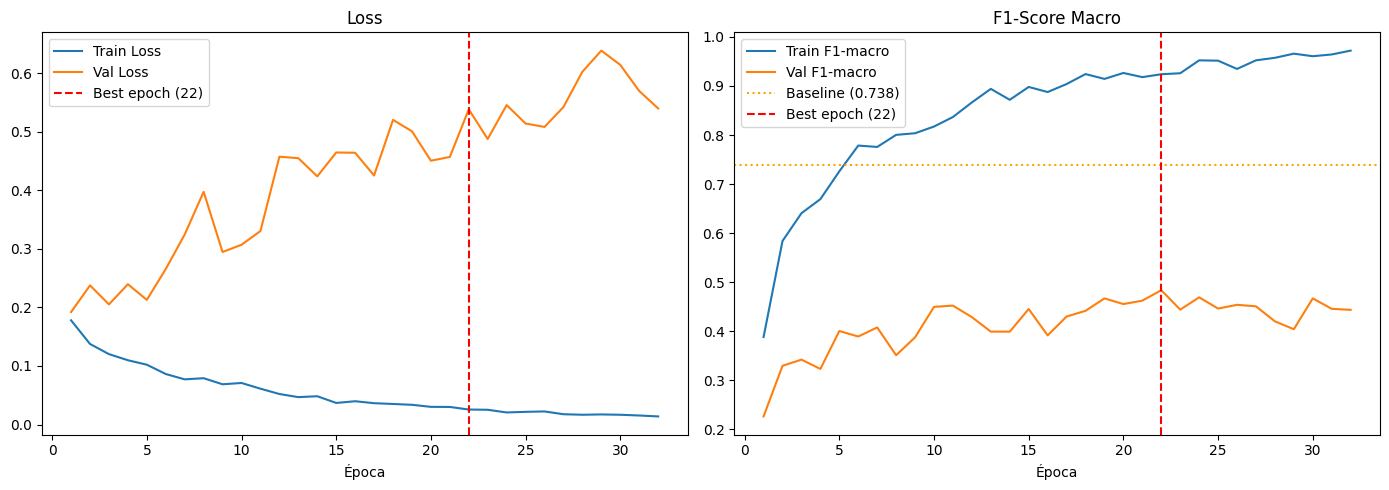

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Época')

axes[1].plot(epochs_range, history['train_f1'], label='Train F1-macro')
axes[1].plot(epochs_range, history['val_f1'],   label='Val F1-macro')
axes[1].axhline(0.738, color='orange', linestyle=':', label='Baseline (0.738)')
axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_title('F1-Score Macro'); axes[1].legend(); axes[1].set_xlabel('Época')

plt.tight_layout()
plt.savefig('training_curves_v4_PM.png', dpi=150)
plt.show()

## 7. Avaliação no Conjunto de Teste

In [10]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_f1 = f1_score(all_labels, all_preds, average='macro')
print(f'\n🎯 Test F1-Score (macro): {test_f1:.4f}  (baseline: 0.738)')
print(f'   Delta vs baseline: {test_f1 - 0.738:+.4f}\n')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Guardar probabilidades para ensemble
np.save('test_probs_efficientnet_v4_PM.npy', all_probs)
np.save('test_labels_v4_PM.npy', all_labels)
print('✅ Probabilidades guardadas para ensemble')


🎯 Test F1-Score (macro): 0.4943  (baseline: 0.738)
   Delta vs baseline: -0.2437

               precision    recall  f1-score   support

Biliary_Leaks     0.5000    0.1176    0.1905        17
    Lithiasis     0.6241    0.7154    0.6667       123
       Normal     0.3939    0.6047    0.4771        43
    Stricture     0.8036    0.5357    0.6429        84

     accuracy                         0.6030       267
    macro avg     0.5804    0.4934    0.4943       267
 weighted avg     0.6356    0.6030    0.5983       267

✅ Probabilidades guardadas para ensemble


## 8. Matriz de Confusão

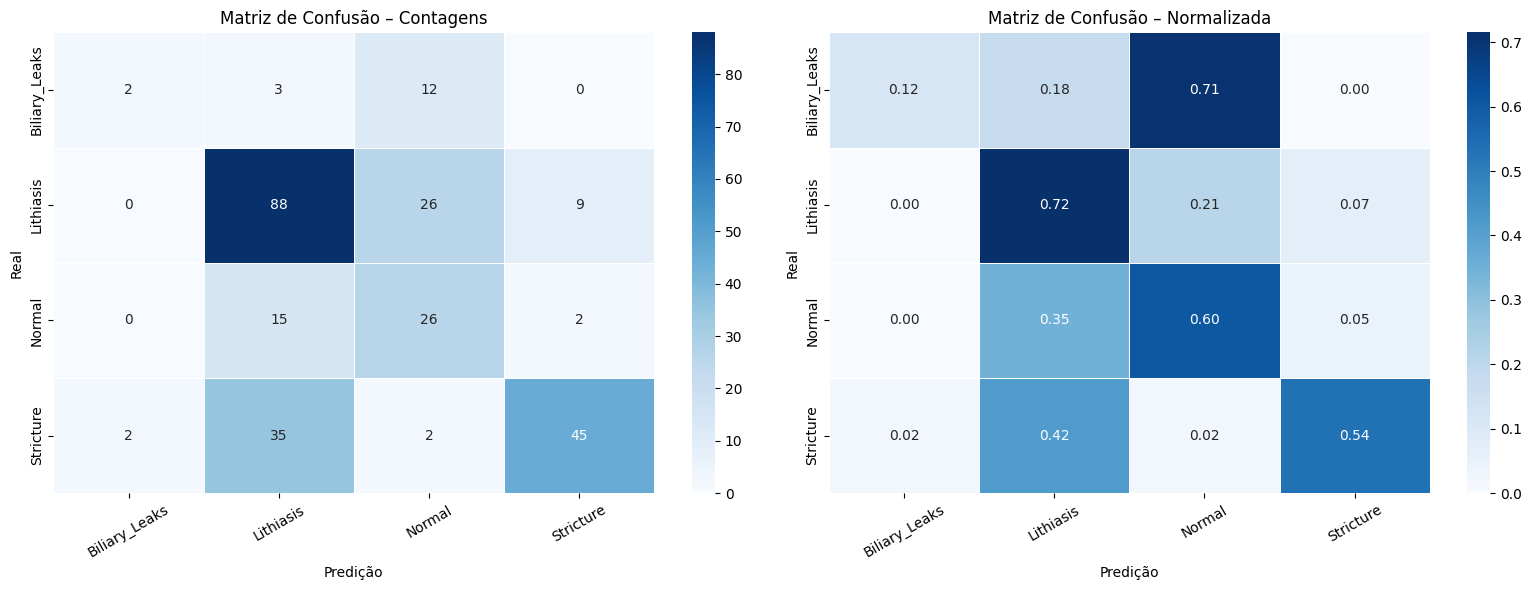

In [11]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(axes,
                                  [cm, cm_norm],
                                  ['d', '.2f'],
                                  ['Contagens', 'Normalizada']):
    sns.heatmap(data, annot=True, fmt=fmt, xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', ax=ax, linewidths=0.5)
    ax.set_title(f'Matriz de Confusão – {title}')
    ax.set_xlabel('Predição'); ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix_efficientnet_v4_PM.png', dpi=150)
plt.show()

## 9. AUC-ROC por Classe

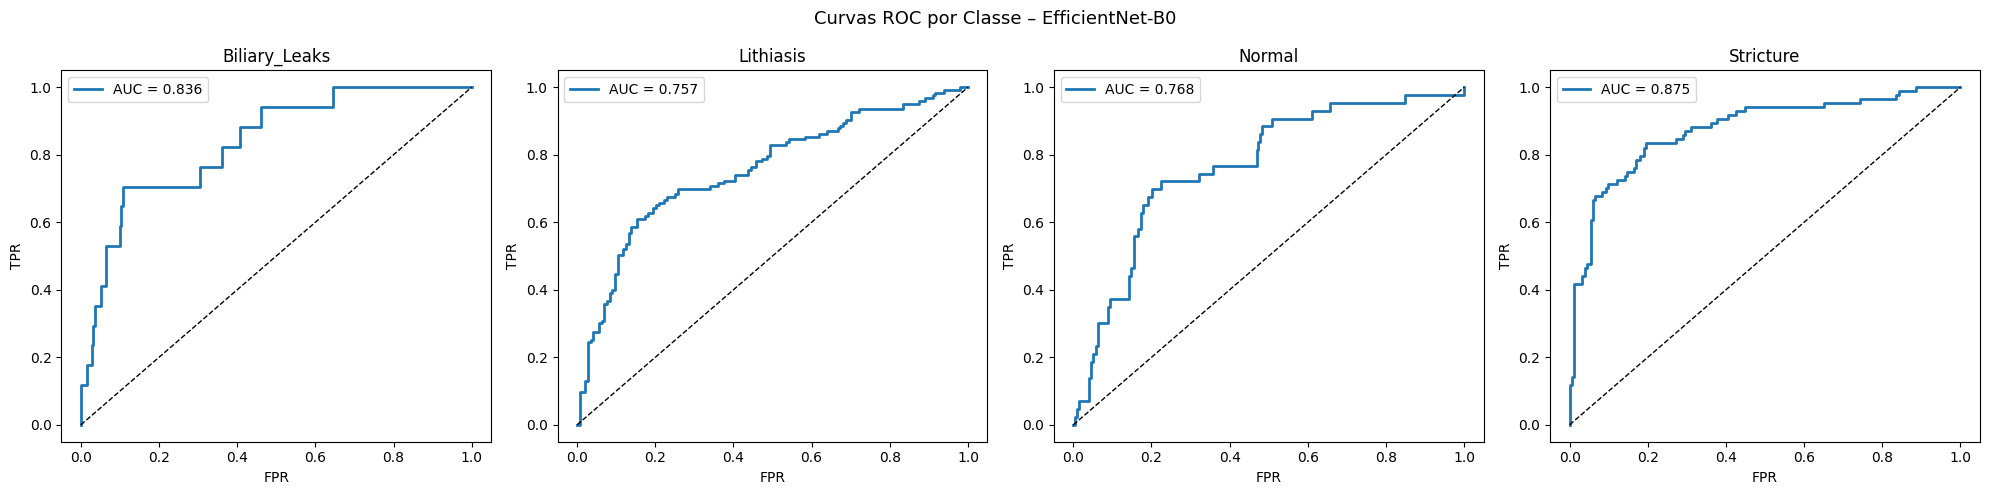

In [12]:
from sklearn.metrics import roc_curve, auc

labels_bin = label_binarize(all_labels, classes=range(NUM_CLASSES))

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))
for i, (ax, cls) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(cls); ax.legend(); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')

plt.suptitle('Curvas ROC por Classe – EfficientNet-B0', fontsize=13)
plt.tight_layout()
plt.savefig('roc_curves_efficientnet_v4_PM.png', dpi=150)
plt.show()